In [3]:
using DataFrames, XLSX, CSV
using CairoMakie

In [69]:
function filter_rangex(df::DataFrame, column::String, low, high)
    return filter(row -> low ≤ row[column] ≤ high, df)
end

filter_rangex (generic function with 1 method)

In [70]:
df= XLSX.readtable("250930_3PBModified.xlsx", "Sheet1") |> DataFrame

Row,N,Separation,Precrack,CrackFront,CrackClosed,dy,S_AlleMax,S_StahlMax,S_KlebebandMean,S_KlebebandMax,u_AlleMax,u_KlebebandMean,u_KlebebandMax,Sy_ParyleneMin,Sy_ParyleneMax,Sx_ParyleneMin,Sx_ParyleneMax,Sx_SiMin,Sx_SiMax,Sy_SiMin,Sy_SiMax,Fx_Front,Fy_Front,Fx_SiPa,Fy_SiPa,P,dx_Si,dx_Parylene,dy_Si,dy_Parylene,deltay_Si,deltay_Parylene,uy_ParyleneMin,uy_ParyleneMax,uy_ParyleneMean,ux_ParyleneMin,ux_ParyleneMean,ux_ParyleneMax,uxy_AlleMax,uxy_KlebebandMax,uxy_SiMin,uxy_SiMax,uxy_SiMean,uxy_ParyleneMin,uxy_ParyleneMax,uxy_ParyleneMean
,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any
1,1,10,10,0.001,0.001,0.5,224.22,223.06,12.5468,60.2868,0.0586835,0.00448967,0.0233856,-46957768,27788113,-24257916,30246013,-14100074,32540470,-1.21551e7,117261048,-0.0657878,-0.10013,-24.7873,-7.73197,2.54349,0.00443092,0.00438991,0.0851213,0.0850332,0.0850275,0.00438237,-0.0354806,0.0174578,0.000240684,-0.0158599,-4.04117e-5,0.0182198,0.0849306,0.0221642,-1.34157e-5,0.000407457,3.06399e-5,-0.0179377,0.0849306,0.0184952
2,2,10,10,0.001,0.001,0.75,337.603,335.855,18.9379,88.5087,0.0854878,0.00677638,0.0339317,-7.01568e7,4.68157e7,-3.45636e7,4.47341e7,-2.03391e7,5.49168e7,-1.82821e7,1.77013e8,-0.0924096,-0.167272,-37.5192,-11.6372,3.83374,0.00654119,0.00648565,0.127802,0.127658,0.127662,0.00647806,-0.0536585,0.027889,0.000368385,-0.0223675,-5.80507e-5,0.0247693,0.122948,0.0324584,-3.98142e-5,0.000607495,4.62561e-5,-0.0264079,0.122948,0.0278548
3,3,10,10,0.001,0.001,1,451.418,449.081,25.3634,116.546,0.112078,0.00907545,0.0443542,-93553776,74182520,-45177851,61032884,-26690468,91807368,-24401360,237774768,-0.117561,-0.251632,-50.265,-15.5483,5.13419,0.00864433,0.00857322,0.170164,0.169973,0.169978,0.00856658,-0.071949,0.0473994,0.000505517,-0.0287347,-7.80558e-5,0.0298665,0.160327,0.042621,-9.88887e-5,0.00089727,6.19481e-5,-0.0347985,0.160327,0.0372471
4,4,10,10,0.001,0.001,1.25,565.959,562.821,31.8344,144.916,0.148299,0.0113908,0.0545443,-118967848,103351076,-54565086,76638920,-32801422,134413744,-30497715,298784800,-0.139798,-0.341577,-63.024,-19.4306,6.43282,0.0107396,0.0106545,0.212624,0.212384,0.212391,0.0106502,-0.0943329,0.0692338,0.000648026,-0.0334802,-0.000107761,0.0336176,0.202974,0.0529211,-0.000172203,0.00129015,7.7693e-5,-0.0570714,0.202974,0.0466514
5,5,10,10,0.001,0.001,1.5,680.032,676.262,38.3148,172.376,0.185373,0.0137096,0.0652512,-148449408,132689336,-64917012,92062168,-38927678,180801488,-36583662,360008032,-0.161758,-0.431707,-75.8133,-23.3112,7.73279,0.0128327,0.0127336,0.255089,0.254802,0.254809,0.0127318,-0.11665,0.0912995,0.000785307,-0.0399292,-0.000126087,0.0371299,0.239276,0.0630087,-0.000254915,0.00171542,9.34439e-5,-0.0604695,0.239276,0.0560628
6,6,10,10,0.001,0.001,2,908.98,903.941,51.3016,227.371,0.259556,0.0183565,0.086873,-209553408,191417120,-97178392,122388336,-51096072,281203184,-48731088,482849696,-0.204919,-0.612236,-101.432,-31.044,10.3324,0.017028,0.0169014,0.340046,0.339667,0.339673,0.0169047,-0.162554,0.135678,0.00106002,-0.0522357,-0.00016333,0.0436395,0.328816,0.0835042,-0.000439309,0.00263126,0.000124971,-0.0664116,0.328816,0.074897
7,7,10,10,0.001,0.001,2.25,1022.84,1017.17,57.7723,255.426,0.294404,0.0206718,0.0978688,-241265152,218874920,-113182360,136642392,-5.80637e7,334823592,-54879388,545256064,-0.225693,-0.696698,-114.16,-34.992,11.6482,0.0191113,0.0189716,0.380858,0.380437,0.380439,0.0189771,-0.186659,0.156398,0.00119562,-0.0582007,-0.00018241,0.0478764,0.371632,0.094085,-0.000539623,0.00311893,0.000140674,-0.0707555,0.371632,0.0842837
8,8,10,10,0.001,0.001,2.5,1138.16,1131.27,64.2912,283.254,0.331023,0.0230041,0.108797,-272946560,247909024,-129461504,151446440,-6.80277e7,385909912,-60936550,607839744,-0.246969,-0.786019,-127.018,-38.8631,12.9558,0.0211913,0.0210382,0.422925,0.42246,0.42246,0.0210464,-0.21063,0.17841,0.00133326,-0.0640138,-0.000202091,0.0527784,0.

In [71]:
df=filter_rangex(df, "dy", 0, 1.5)

Row,N,Separation,Precrack,CrackFront,CrackClosed,dy,S_AlleMax,S_StahlMax,S_KlebebandMean,S_KlebebandMax,u_AlleMax,u_KlebebandMean,u_KlebebandMax,Sy_ParyleneMin,Sy_ParyleneMax,Sx_ParyleneMin,Sx_ParyleneMax,Sx_SiMin,Sx_SiMax,Sy_SiMin,Sy_SiMax,Fx_Front,Fy_Front,Fx_SiPa,Fy_SiPa,P,dx_Si,dx_Parylene,dy_Si,dy_Parylene,deltay_Si,deltay_Parylene,uy_ParyleneMin,uy_ParyleneMax,uy_ParyleneMean,ux_ParyleneMin,ux_ParyleneMean,ux_ParyleneMax,uxy_AlleMax,uxy_KlebebandMax,uxy_SiMin,uxy_SiMax,uxy_SiMean,uxy_ParyleneMin,uxy_ParyleneMax,uxy_ParyleneMean
,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any
1,1,10,10,0.001,0.001,0.5,224.22,223.06,12.5468,60.2868,0.0586835,0.00448967,0.0233856,-46957768,27788113,-24257916,30246013,-14100074,32540470,-1.21551e7,117261048,-0.0657878,-0.10013,-24.7873,-7.73197,2.54349,0.00443092,0.00438991,0.0851213,0.0850332,0.0850275,0.00438237,-0.0354806,0.0174578,0.000240684,-0.0158599,-4.04117e-5,0.0182198,0.0849306,0.0221642,-1.34157e-5,0.000407457,3.06399e-5,-0.0179377,0.0849306,0.0184952
2,2,10,10,0.001,0.001,0.75,337.603,335.855,18.9379,88.5087,0.0854878,0.00677638,0.0339317,-7.01568e7,4.68157e7,-3.45636e7,4.47341e7,-2.03391e7,5.49168e7,-1.82821e7,1.77013e8,-0.0924096,-0.167272,-37.5192,-11.6372,3.83374,0.00654119,0.00648565,0.127802,0.127658,0.127662,0.00647806,-0.0536585,0.027889,0.000368385,-0.0223675,-5.80507e-5,0.0247693,0.122948,0.0324584,-3.98142e-5,0.000607495,4.62561e-5,-0.0264079,0.122948,0.0278548
3,3,10,10,0.001,0.001,1,451.418,449.081,25.3634,116.546,0.112078,0.00907545,0.0443542,-93553776,74182520,-45177851,61032884,-26690468,91807368,-24401360,237774768,-0.117561,-0.251632,-50.265,-15.5483,5.13419,0.00864433,0.00857322,0.170164,0.169973,0.169978,0.00856658,-0.071949,0.0473994,0.000505517,-0.0287347,-7.80558e-5,0.0298665,0.160327,0.042621,-9.88887e-5,0.00089727,6.19481e-5,-0.0347985,0.160327,0.0372471
4,4,10,10,0.001,0.001,1.25,565.959,562.821,31.8344,144.916,0.148299,0.0113908,0.0545443,-118967848,103351076,-54565086,76638920,-32801422,134413744,-30497715,298784800,-0.139798,-0.341577,-63.024,-19.4306,6.43282,0.0107396,0.0106545,0.212624,0.212384,0.212391,0.0106502,-0.0943329,0.0692338,0.000648026,-0.0334802,-0.000107761,0.0336176,0.202974,0.0529211,-0.000172203,0.00129015,7.7693e-5,-0.0570714,0.202974,0.0466514
5,5,10,10,0.001,0.001,1.5,680.032,676.262,38.3148,172.376,0.185373,0.0137096,0.0652512,-148449408,132689336,-64917012,92062168,-38927678,180801488,-36583662,360008032,-0.161758,-0.431707,-75.8133,-23.3112,7.73279,0.0128327,0.0127336,0.255089,0.254802,0.254809,0.0127318,-0.11665,0.0912995,0.000785307,-0.0399292,-0.000126087,0.0371299,0.239276,0.0630087,-0.000254915,0.00171542,9.34439e-5,-0.0604695,0.239276,0.0560628
6,11,10,20,0.001,0.001,0.5,224.198,223.038,12.5204,60.2186,0.0900676,0.00448043,0.0233557,-46919376,47968004,-24170642,58614728,-12935450,31629096,-12154176,117269168,-0.127688,-0.157288,-24.7456,-7.70036,2.5433,0.00442825,0.00434269,0.0852742,0.0851422,0.0850865,0.0043,-0.0354773,0.0253726,0.000251235,-0.0158246,1.33093e-5,0.03755,0.119165,0.0221377,-1.35991e-5,0.000407694,3.05692e-5,-0.018045,0.119165,0.018572
7,12,10,20,0.001,0.001,0.75,337.567,335.819,18.8979,88.4157,0.145593,0.00676238,0.0338871,-70088016,86533240,-34528901,88472780,-17625781,54850322,-18280606,177021600,-0.181432,-0.271539,-37.4564,-11.5691,3.83343,0.00653729,0.00641562,0.128033,0.127836,0.127752,0.0063587,-0.0536553,0.0487087,0.00039466,-0.022311,1.70987e-5,0.0512947,0.192331,0.0324213,-3.98402e-5,0.000607975,4.61228e-5,-0.0266432,0.192331,0.0279654
8,13,10,20,0.001,0.001,1,451.368,449.031,25.3094,116.428,0.202784,0.00905654,0.0442955,-93470848,126736028,-45135568,117852984,-22853685,91684144,-24399274,237783040,-0.233375,-0.389776,-50.1848,-15.4588,5.13376,0.00863915,0.00848149,0.170474,0.170214,0.170101,0.00841114,-0.0719589,0.0758046,0.000540698,-0.0286634,1.9986e-5,0.06

## Figure Stress Curves

In [72]:
# Plot the first curve with lines and markers
fig = Figure(resolution = (1200, 1200))
font=24
ax1_1 = Axis(fig[1,1],
    xlabel = L"w (mm)",
    ylabel = L"P (N)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


ax2_1 = Axis(fig[1,2],
    xlabel = L"w (mm)",
    ylabel = L"σ_x (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_1 = Axis(fig[1,3],
    xlabel = L"w (um)",
    ylabel = L"σ_y (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax4_1 = Axis(fig[2,1],
    xlabel = L"a (um)",
    ylabel = L"σ_x (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax5_1 = Axis(fig[2,2],
    xlabel = L"a (um)",
    ylabel = L"σ_y (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)





Axis with 0 plots:


## Figure VCCT Curves

In [73]:
# Plot the first curve with lines and markers
fig2 = Figure(resolution = (1200, 1200))
font=24


ax1_2 = Axis(fig2[1,1],
    xlabel = L"w (mm)",
    ylabel = L"ux1-ux2  (um)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


ax2_2 = Axis(fig2[1,2],
    xlabel = L"w (mm)",
    ylabel = L"uy1-uy2 (um)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


ax3_2 = Axis(fig2[1,3],
    xlabel = L"ux1-ux2  (um)",
    ylabel = L"Fx (N)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax4_2 = Axis(fig2[2,1],
    xlabel = L"uy1-uy2  (um)",
    ylabel = L"Fy (N)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



ax5_2 = Axis(fig2[2,2],
    xlabel = L"δy (um)",
    ylabel = L"Fy (N)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax6_2 = Axis(fig2[3,1],
    xlabel = L"w (mm)",
    ylabel = L"GI(J/m2)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax7_2 = Axis(fig2[3,2],
    xlabel = L"w (mm)",
    ylabel = L"GII(J/m2)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


Axis with 0 plots:


## Functions

In [75]:
function filter_range(df::DataFrame, column::String, a0)
    return filter(row -> row[column] ==a0, df)
end

filter_range (generic function with 1 method)

In [76]:
function plotBendingCurves(ax1,ax2,ax3,ax4,ax5,df)
    Makie.scatter!(ax1,df[!,:dy],df[!,:P])
    Makie.lines!(ax1,df[!,:dy],df[!,:P])

    Makie.scatter!(ax2,df[!,:dy],-df[!,:σx_front])
    Makie.lines!(ax2,df[!,:dy],-df[!,:σx_front])

    Makie.scatter!(ax3,df[!,:dy],-df[!,:σy_front])
    Makie.lines!(ax3,df[!,:dy],-df[!,:σy_front])


    Makie.scatter!(ax4,df[!,:Precrack],-df[!,:σx_front])
    Makie.lines!(ax4,df[!,:Precrack],-df[!,:σx_front])


    Makie.scatter!(ax5,df[!,:Precrack],-df[!,:σy_front])
    Makie.lines!(ax5,df[!,:Precrack],-df[!,:σy_front])


end


plotBendingCurves (generic function with 1 method)

In [77]:
function plotVCCTCurves(ax1,ax2,ax3,ax4,ax5,ax6,ax7,df)
    Makie.scatter!(ax1,df[!,:dy],df[!,:δ_x])
    Makie.lines!(ax1,df[!,:dy],df[!,:δ_x])

    Makie.scatter!(ax2,df[!,:dy],df[!,:δ_y])
    Makie.lines!(ax2,df[!,:dy],df[!,:δ_y])

    Makie.scatter!(ax3,-df[!,:δ_x],-df[!,:Fx_Front])
    Makie.lines!(ax3,-df[!,:δ_x],-df[!,:Fx_Front])


    Makie.scatter!(ax4,df[!,:δ_y],-df[!,:Fy_Front])
    Makie.lines!(ax4,df[!,:δ_y],-df[!,:Fy_Front])

    Makie.scatter!(ax5,df[!,:delta_y],-df[!,:Fy_Front])
    Makie.lines!(ax5,df[!,:delta_y],-df[!,:Fy_Front])

    Makie.scatter!(ax6,df[!,:dy],-df[!,:GI])
    Makie.lines!(ax6,df[!,:dy],-df[!,:GI])

    Makie.scatter!(ax7,df[!,:dy],-df[!,:GII])
    Makie.lines!(ax7,df[!,:dy],-df[!,:GII])
end

plotVCCTCurves (generic function with 1 method)

In [78]:
width=2*1e-3 #m
delta_crack=0.001 * 1e-3 #m 
s_crack=width*delta_crack #m2

2.0e-9

In [79]:
df[!,:GI]=(df[!,:Fy_Front].*(df[!,:dy_Parylene]-df[!,:dy_Si])*-1*1e-3)/(2*s_crack)
df[!,:GII]=(df[!,:Fx_Front].*(df[!,:dx_Parylene]-df[!,:dx_Si])*-1*1e-3)/(2*s_crack)
df[!,:δ_x]=(-df[!,:dx_Parylene]+df[!,:dx_Si])*1000
df[!,:δ_y]=(-df[!,:dy_Parylene]+df[!,:dy_Si])*1000
df[!,:σx_front]=df[!,:Fx_Front]*1e-6./s_crack #MPa
df[!,:σy_front]=df[!,:Fy_Front]*1e-6./s_crack #MPa
df[!,:delta_y]=(-df[!,:deltay_Parylene]+df[!,:deltay_Si])*1000 ## Aperture in um


75-element Vector{Float64}:
  80.64510120675544
 121.18364358320748
 161.4112752577057
 201.74109067738732
 242.07772366935387
  80.7864703347149
 121.39364298491223
 161.6899362488758
 202.08843852742578
 242.49480429716579
   ⋮
 135.22241852115198
 179.91811228057426
 224.97895406559093
 269.9432616282138
  92.52708014173542
 138.97812323193594
 184.81681399862202
 231.21515005186606
 277.41902522393497

## Pre crack 10 um

In [ ]:
df_10=Float64.(filter_range(df,"PrecrackRechts",10))

Row,N,PrecrackRechts,PrecrackLinks,dy,CrackFront,Crackclosed,CrackFrontRechts,CrackClosedRechts,Fx_Front,Fy_Front,Fx_SiPa,Fy_SiPa,S_Alle,S_Stahl,S_KlebebandMax,S_KlebebandMean,u_AlleMax,u_KlebebandMax,u_KlebebandMean,Sy_ParyleneMax,Sy_ParyleneMin,Sx_ParyleneMax,Sx_ParyleneMin,Sx_SiMax,Sx_SiMin,Sy_SiMax,Sy_SiMin,uy_ParyleneMax,uy_ParyleneMean,ux_ParyleneMax,ux_ParyleneMean,uy_ParyleneMin,ux_ParyleneMin,ux_SiMin,ux_SiMax,ux_SiMean,uy_SiMin,uy_SiMax,uy_SiMean,uxy_AlleMax,uxy_ParyleneMax,uxy_ParyleneMean,uxy_ParyleneMin,uxy_SiMean,uxy_SiMax,uxy_SiMin,uxy_KlebebandMax,Fy,dy_Si,dy_Parylene,dx_Parylene,dx_Si,deltay_Parylene,deltay_Si,P,G2,δ_x,δ_y,σx_front,σy_front
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.0,10.0,10.0,0.5,0.001,0.001,0.001,0.001,-0.0559956,-0.0127751,-0.0782602,0.0222271,82.5565,82.5565,0.346084,0.0548697,0.0213244,0.00692168,0.00109954,2.31346,-4.91346,17.8069,-3.57205,5.28722,-4.88235,0.324758,-1.94865,0.000333226,-9.81473e-5,0.0171547,0.000259777,-0.00727286,-0.00153016,-2.47489e-5,3.00492e-5,9.76808e-7,-1.14145e-5,8.93279e-7,-2.45088e-7,0.0150462,0.0150462,-3.35199e-6,-0.0202665,2.57357e-9,6.41343e-5,-5.29016e-5,0.00559524,1.12238,500.509,500.54,6.02866,5.96075,500.581,500.528,1.12238,0.95061,-0.0679061,-0.0313157,-27.9978,-6.38755
2,1.0,10.0,10.0,0.75,0.001,0.001,0.001,0.001,-0.0967563,-0.0224562,-0.123434,0.0355084,123.876,123.876,0.531928,0.0839908,0.0356672,0.0106386,0.00168319,3.85139,-8.08829,29.7911,-6.75008,9.27694,-8.55516,0.646327,-3.47148,0.00107784,-0.000151494,0.028781,0.000400723,-0.0123704,-0.00334739,-4.33145e-5,5.2712e-5,1.58744e-6,-1.99789e-5,1.57072e-6,-4.00105e-7,0.0265202,0.0265202,-5.10968e-6,-0.0336667,6.1188e-9,0.000113271,-8.86283e-5,0.00846604,1.68469,750.807,750.861,9.04099,8.95054,750.93,750.835,1.68469,2.18788,-0.0904492,-0.0542495,-48.3782,-11.2281
3,2.0,10.0,10.0,1.0,0.001,0.001,0.001,0.001,-0.133256,-0.0327636,-0.177319,0.0487681,165.264,165.264,0.718098,0.113894,0.0493655,0.014362,0.00228237,5.18767,-11.1563,41.7414,-8.07631,12.6754,-12.1254,0.896426,-4.92101,0.00176347,-0.000206216,0.0404541,0.000544183,-0.0176524,-0.00344169,-6.12746e-5,7.21818e-5,2.24209e-6,-2.84934e-5,2.54533e-6,-5.66504e-7,0.0374589,0.0374589,-6.48144e-6,-0.0451718,9.12698e-9,0.000159464,-0.000120485,0.0107967,2.2499,1001.1,1001.18,12.0465,11.9358,1001.28,1001.14,2.2499,3.68933,-0.110744,-0.0769505,-66.6282,-16.3818
4,3.0,10.0,10.0,1.25,0.001,0.001,0.001,0.001,-0.169187,-0.0430943,-0.234987,0.061813,206.715,206.715,0.904109,0.144438,0.0630438,0.0180822,0.00289432,6.50436,-14.1846,53.7026,-9.01537,15.9475,-15.6409,1.14617,-6.34784,0.00242055,-0.000262681,0.0521496,0.000691732,-0.0229688,-0.00432556,-7.89332e-5,9.0956e-5,2.92363e-6,-3.69628e-5,3.56219e-6,-7.39667e-7,0.0483344,0.0483344,-7.84657e-6,-0.058264,1.19048e-8,0.000205247,-0.000151994,0.0132632,2.81538,1251.39,1251.49,15.062,14.929,1251.62,1251.44,2.81538,5.62566,-0.133005,-0.0997679,-84.5935,-21.5472
5,4.0,10.0,10.0,1.5,0.001,0.001,0.001,0.001,-0.203909,-0.0535385,-0.295483,0.0747011,248.116,248.116,1.08948,0.175199,0.0764972,0.0217896,0.0035106,7.75133,-17.0936,65.6074,-9.38017,19.0978,-19.1078,1.35187,-7.75724,0.00296473,-0.000319485,0.0638179,0.00083983,-0.0283298,-0.0053324,-9.63194e-5,0.000109089,3.6173e-6,-4.53965e-5,4.64748e-6,-9.1602e-7,0.0590541,0.0590541,-9.04443e-6,-0.071188,1.46076e-8,0.00025053,-0.000182162,0.0158177,3.37974,1501.68,1501.8,18.0756,17.921,1501.96,1501.74,3.37974,7.88209,-0.15462,-0.122236,-101.955,-26.7693
6,5.0,10.0,10.0,1.75,0.001,0.001,0.001,0.001,-0.238186,-0.0640414,-0.356721,0.087595,

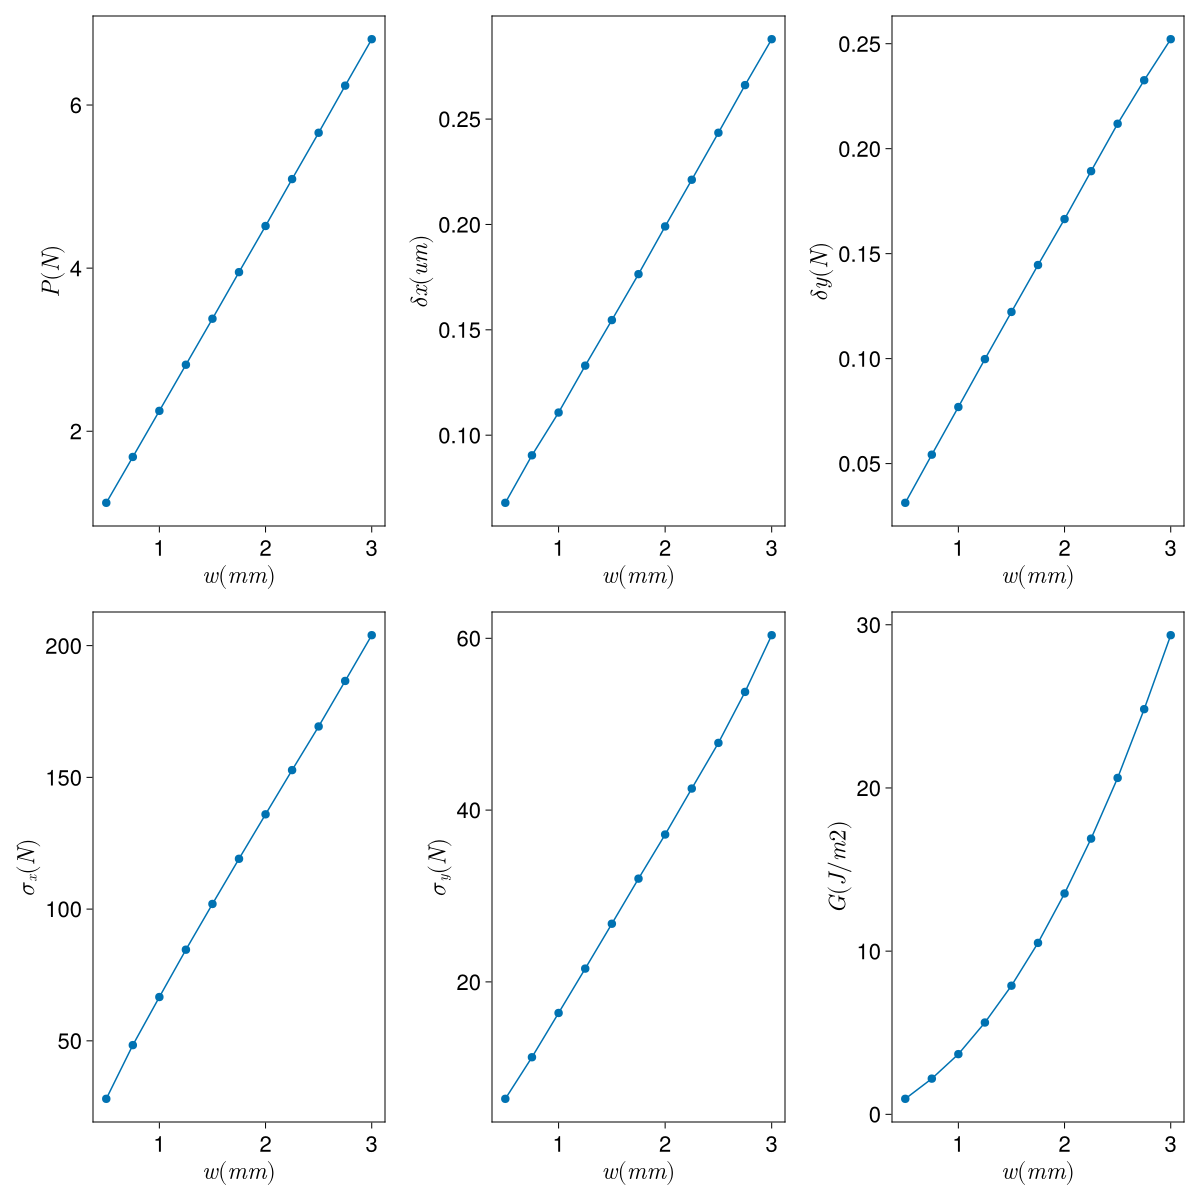

In [69]:
Makie.scatter!(ax1,df_10[!,:dy],df_10[!,:P])
Makie.lines!(ax1,df_10[!,:dy],df_10[!,:P])

Makie.scatter!(ax2,df_10[!,:dy],-df_10[!,:δ_x])
Makie.lines!(ax2,df_10[!,:dy],-df_10[!,:δ_x])

Makie.scatter!(ax3,df_10[!,:dy],-df_10[!,:δ_y])
Makie.lines!(ax3,df_10[!,:dy],-df_10[!,:δ_y])

Makie.scatter!(ax4,df_10[!,:dy],-df_10[!,:σx_front])
Makie.lines!(ax4,df_10[!,:dy],-df_10[!,:σx_front])


Makie.scatter!(ax5,df_10[!,:dy],-df_10[!,:σy_front])
Makie.lines!(ax5,df_10[!,:dy],-df_10[!,:σy_front])

Makie.scatter!(ax6,df_10[!,:dy],df_10[!,:G2])
Makie.lines!(ax6,df_10[!,:dy],df_10[!,:G2])



fig


## Pre crack 10 50 100 200 300 500

In [80]:

for i in [10, 50, 100, 300]

    df_filter=Float64.(filter_range(df,"Precrack",i))
    plotBendingCurves(ax1_1,ax2_1,ax3_1,ax4_1,ax5_1,df_filter)
    plotVCCTCurves(ax1_2,ax2_2,ax3_2,ax4_2,ax5_2,ax6_2,ax7_2,df_filter)
end


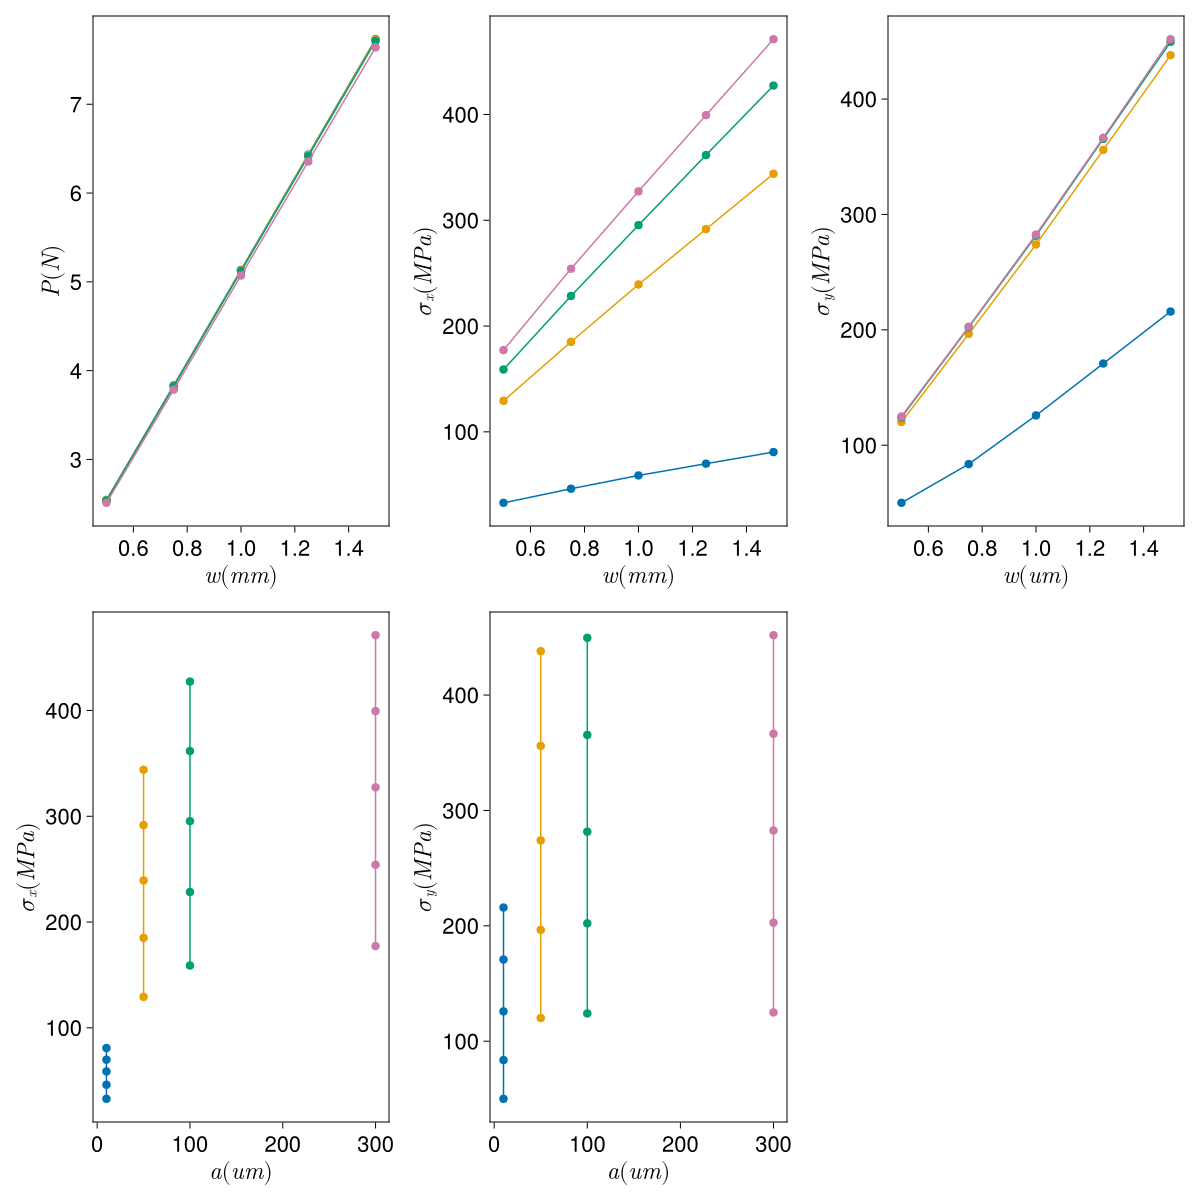

In [81]:
fig

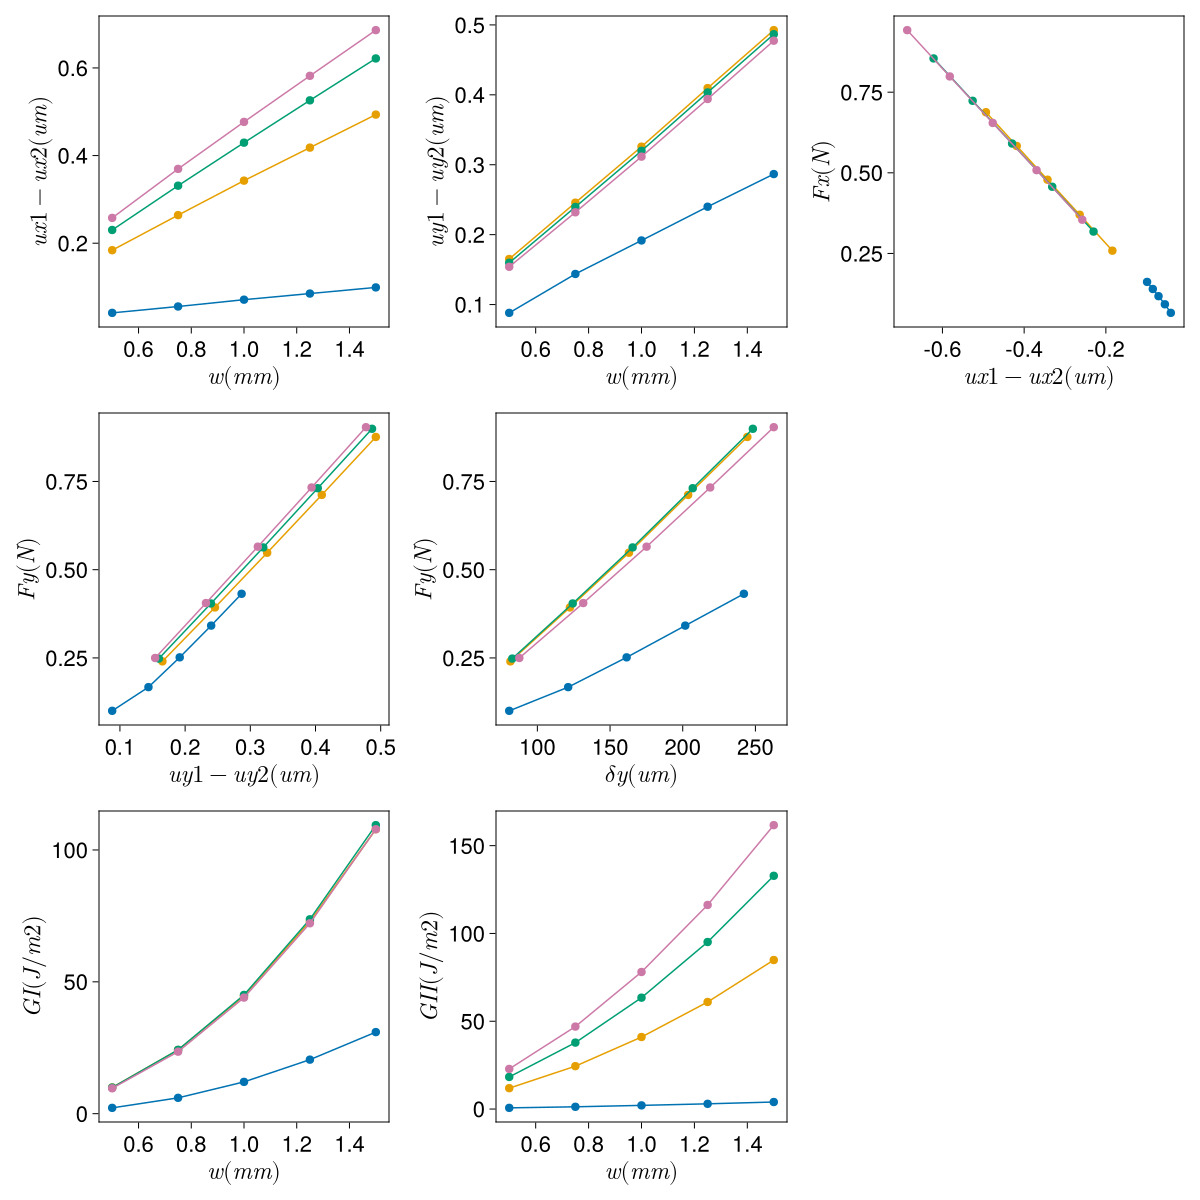

In [82]:
fig2